In [1]:
# Author: Shiva Thanay Pandiri 19 December, 2025
# Purpose: To cross-match different catalogues and perform initial multi-wavelength analysis.

### **Loading Modules and Files**

In [2]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import gridspec
from matplotlib import colors
from astropy.table import Table, hstack, join
from astropy.io import ascii
from astropy.cosmology import Planck18 as cosmo 
import seaborn as sns
import pandas as pd
from astropy import units as u

In [3]:
(1/3600)*(2*np.pi/360)

4.84813681109536e-06

In [4]:
np.radians(1/3600)

np.float64(4.84813681109536e-06)

In [5]:
xray_file = Table.read("D:/Project - Sim Cat/data/eFEDS_c001_main_fluxes.fits") # TODO: change path to relative
#g09_file = fits.open("D:/Project - Sim Cat/data/G09uW-s5-g5-gdd-wP-gal.fits") # TODO: change path to relative
#g09_table = Table(g09_file[1].data)
#eFEDS_AGN = fits.open("D:/Project - Sim Cat/data/eFEDS_AGN_coords.fits")
#eFEDS_AGN_table = Table(eFEDS_AGN[1].data)
desi_bgs = fits.open("D:/Project - Sim Cat/final_desi_sample.fits")
desi_bgs_table = Table(desi_bgs[1].data)

In [6]:
desi_bgs_table

Z,ZERR,TARGET_RA,TARGET_DEC,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,DESINAME
float64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str22
0.13898956673225846,3.0236858026372503e-06,155.43134937687415,-5.020879914211334,10.791448,15.219741,18.2624,11.768634,4.3970227,156.49512,44.035294,13.169145,2.3314593,0.523089,DESI J155.4313-05.0208
0.12369332314605871,6.971081504249075e-06,141.9405462504283,0.7834478480667347,8.560033,19.490778,39.065975,59.9772,43.722584,424.4799,168.36731,25.342934,1.8933736,0.5524632,DESI J141.9405+00.7834
0.32603368079705597,8.02807931492466e-05,168.52167515724926,-8.275008393503898,4.241499,19.49078,45.088734,84.03748,49.69418,150.62158,31.781277,28.487705,1.4942359,0.44179797,DESI J168.5216-08.2750
0.3815439030626357,9.743594791739278e-05,185.58268619595572,44.51868452603134,4.7304196,19.490782,43.451187,71.68228,52.377857,143.03955,32.349274,11.690382,2.1834574,0.70902675,DESI J185.5826+44.5186
0.18406139701518298,1.942970502973537e-05,126.88409325432238,27.519669011669365,10.477374,19.49079,29.893715,23.474257,19.545805,362.96054,94.08276,13.343519,1.9267869,0.48869118,DESI J126.8840+27.5196
0.18495894446225364,2.9592460211482208e-05,254.34850211471644,73.1365577120007,7.1577973,19.490799,40.796963,49.648888,34.817497,194.0414,87.03895,32.125698,3.639108,1.4511821,DESI J254.3485+73.1365
0.16226698531588016,1.4315172714534555e-05,241.55932962957095,8.526349537152665,9.623672,19.4908,33.774548,34.19076,22.63946,287.99896,118.24031,29.412933,2.385509,0.66109884,DESI J241.5593+08.5263
0.20888364498354994,6.042588905406987e-05,167.011356829209,69.00750595641708,6.244992,19.490803,35.556107,32.97783,26.28021,206.83253,47.469204,42.039513,3.5785463,1.1766899,DESI J167.0113+69.0075
0.30272260843360244,3.867965871364068e-05,210.784090224544,47.04703151988455,6.5181484,19.490807,39.36371,56.67908,43.165085,194.89937,65.04864,16.986195,2.647323,0.84914666,DESI J210.7840+47.0470


In [7]:
xray_file

Name,RA_CORR,DEC_CORR,RADEC_ERR_CORR,ML_FLUX,ML_FLUX_ERR
,deg,deg,arcsec,erg / (s cm2),erg / (s cm2)
bytes22,float64,float64,float64,float32,float32
eFEDS J093700.9+010545,144.25383285520846,1.0959204090623735,3.6204234764894245,6.2095207e-12,3.7595803e-13
eFEDS J091453.4+042636,138.722879100407,4.443384040098805,0.8071033723515371,4.424652e-12,7.132479e-14
eFEDS J085617.8-013805,134.07417045497337,-1.6347450374969688,5.281138955203107,3.993971e-12,3.462835e-13
eFEDS J084025.4+033302,130.10609617356337,3.5508089298077246,1.3945431648151174,3.0862292e-12,8.368503e-14
eFEDS J091639.7+004343,139.16543540517227,0.7287895712585898,4.915522652033729,2.0344483e-12,2.4111263e-13
eFEDS J084441.9+004416,131.17473404403927,0.737924664943407,0.9444610777458614,1.8908553e-12,4.7658915e-14
eFEDS J091702.3-004415,139.25958886351057,-0.7375046618167612,3.6990023966831513,1.509369e-12,3.2599903e-14
eFEDS J091400.3+050651,138.5016280856247,5.114247548661804,1.9156134967220073,1.4491834e-13,1.4028058e-14


In [8]:
xray_file = xray_file.to_pandas()
desi_bgs_table = desi_bgs_table.to_pandas()

In [9]:
type(desi_bgs_table)

pandas.DataFrame

In [10]:
type(xray_file)

pandas.DataFrame

### **Cross-Matching**

In [16]:
# TODO: define a function that calculates angular distance between two sources

def angular_distance(coord1, coord2, ang_type = 'haversine'):

    ra1 = np.radians(coord1[0])
    dec1 = np.radians(coord1[1])
    ra2 = np.radians(coord2[0])
    dec2 = np.radians(coord2[1])

    if ang_type == 'great_circle':
        return np.sqrt(((ra1 - ra2)*np.cos(dec1))**2 + (dec1 - dec2)**2)
    elif ang_type == 'haversine':
        return 2*np.arcsin(np.sqrt(np.sin((dec1 - dec2)/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin((ra1 - ra2)/2)**2))
    else:
        print("Invalid type")
        return None

# TODO: define a function that calculates the angular distance between one source and all the sources in a catalog

def angular_distance2(coord1, coords2, ang_type = 'haversine'):

    ra1 = np.radians(coord1[0])
    dec1 = np.radians(coord1[1])

    ra2 = np.radians(coords2[0])
    dec2 = np.radians(coords2[1])

    if ang_type == 'great_circle':
        return np.sqrt(((ra1 - ra2)*np.cos(dec1))**2 + (dec1 - dec2)**2)
    elif ang_type == 'haversine':
        return 2*np.arcsin(np.sqrt(np.sin((dec1 - dec2)/2)**2 + np.cos(dec1)*np.cos(dec2)*np.sin((ra1 - ra2)/2)**2))
    else:
        print("Invalid type")
        return None
    

# TODO: define a function that iterates over a catalog and calculates the angular distance between each source and the other catalog

def catalog_angular(catalog1: pd.DataFrame, catalog2: pd.DataFrame, tolerance: float) -> list[list, list, list]:

    cat1_indices = []
    cat2_indices = []
    matched_distances = []
    
    coords = np.array([catalog2["TARGET_RA"], catalog2["TARGET_DEC"]])

    for i, (ra, dec) in enumerate(zip(catalog1["RA_CORR"], catalog1["DEC_CORR"])):
        print(f'{i+1}/{len(xray_file["RA_CORR"])}')
        angular_distances = angular_distance2([ra, dec], coords)
        prob_matches = np.where(angular_distances <= tolerance)[0]

        if len(prob_matches) != 0:
            cat1_indices.append(i)
            cat2_indices.append(prob_matches[np.argmin(angular_distances[prob_matches])])
            matched_distances.append(angular_distances[prob_matches].min())

    return [cat1_indices, cat2_indices, matched_distances]


# TODO: define a function that cross-matches two catalogs

def cross_match(catalog1: pd.DataFrame, catalog2: pd.DataFrame, tolerance: float) -> pd.DataFrame:

    if "DESINAME" in catalog1.columns:
        cat_2 = catalog1
        cat_1 = catalog2
    elif "DESINAME" in catalog2.columns:
        cat_1 = catalog1
        cat_2 = catalog2

    results = catalog_angular(cat_1, cat_2, tolerance)

    matched_table = pd.DataFrame({"EFEDS_ID": cat_1["Name"][results[0]],     #TODO: make this non-specific to DESI and eFEDS
                                  "DESI_ID": cat_2["DESINAME"][results[1]],
                                  "RA": cat_1["RA_CORR"][results[0]],
                                  "DEC": cat_1["DEC_CORR"][results[0]],
                                  "RA_2": cat_2["TARGET_RA"][results[1]],
                                  "DEC_2": cat_2["TARGET_DEC"][results[1]],
                                  "RADEC_ERR": cat_1["RADEC_ERR_CORR"][results[0]],
                                  "Z": cat_2["Z"][results[1]],
                                  "ZERR": cat_2["ZERR"][results[1]],
                                  "Distance": results[2]})
    
    return matched_table

# In the end, we will have a block of code which, given two catalogs, will calculate the angular distances between each pair of sources
# of the catalogs. We are only going to keep the pairs whose angular distance is in our tolerance range. At this point, what we have is
# pairs of sources between two catalogs, whose angular distance is in our tolerance range. 

def cross_match_symmetric(catalog1: pd.DataFrame, catalog2: pd.DataFrame, tolerance: float) -> pd.DataFrame:

    forward_match = cross_match(catalog1, catalog2, tolerance)
    backward_match = cross_match(catalog2, catalog1, tolerance)

    symmetric_match = forward_match.merge(backward_match, how='inner', suffixes=("", "_dup")) # merging the two match tables to get the common rows
    symmetric_match = symmetric_match[[c for c in symmetric_match.columns if not c.endswith("_dup")]] # removes the duplicate columns

    return symmetric_match

# The original cross_match function has one short coming when we are dealing with dense catalogs. The problem is, you're taking a source in
# one catalog and trying to find its best match in the other catalog. This can lead to two different sources in catalog 1 having the same 
# best match in the 2nd catalog. Physically this doesn't make any sense, two optical sources cannot become one when we move over to x-ray.
# To solve this, we call cross_match twice, with the catalogs swapped. This removes duplicates, but it takes a lot of time though :(

In [12]:
def to_little_endian_series(s):
    arr = s.to_numpy(copy=False)
    if arr.dtype.byteorder in ('=', '|'):
        return s
    arr_native = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return pd.Series(arr_native, index=s.index, name=s.name)

xray_file = xray_file.apply(to_little_endian_series)
desi_bgs_table = desi_bgs_table.apply(to_little_endian_series)

In [13]:
result = cross_match_symmetric(xray_file, desi_bgs_table, 10**-3)

1/27910
2/27910
3/27910
4/27910
5/27910
6/27910
7/27910
8/27910
9/27910
10/27910
11/27910
12/27910
13/27910
14/27910
15/27910
16/27910
17/27910
18/27910
19/27910
20/27910
21/27910
22/27910
23/27910
24/27910
25/27910
26/27910
27/27910
28/27910
29/27910
30/27910
31/27910
32/27910
33/27910
34/27910
35/27910
36/27910
37/27910
38/27910
39/27910
40/27910
41/27910
42/27910
43/27910
44/27910
45/27910
46/27910
47/27910
48/27910
49/27910
50/27910
51/27910
52/27910
53/27910
54/27910
55/27910
56/27910
57/27910
58/27910
59/27910
60/27910
61/27910
62/27910
63/27910
64/27910
65/27910
66/27910
67/27910
68/27910
69/27910
70/27910
71/27910
72/27910
73/27910
74/27910
75/27910
76/27910
77/27910
78/27910
79/27910
80/27910
81/27910
82/27910
83/27910
84/27910
85/27910
86/27910
87/27910
88/27910
89/27910
90/27910
91/27910
92/27910
93/27910
94/27910
95/27910
96/27910
97/27910
98/27910
99/27910
100/27910
101/27910
102/27910
103/27910
104/27910
105/27910
106/27910
107/27910
108/27910
109/27910
110/27910
111/2791

ValueError: array length 27869 does not match index length 54017

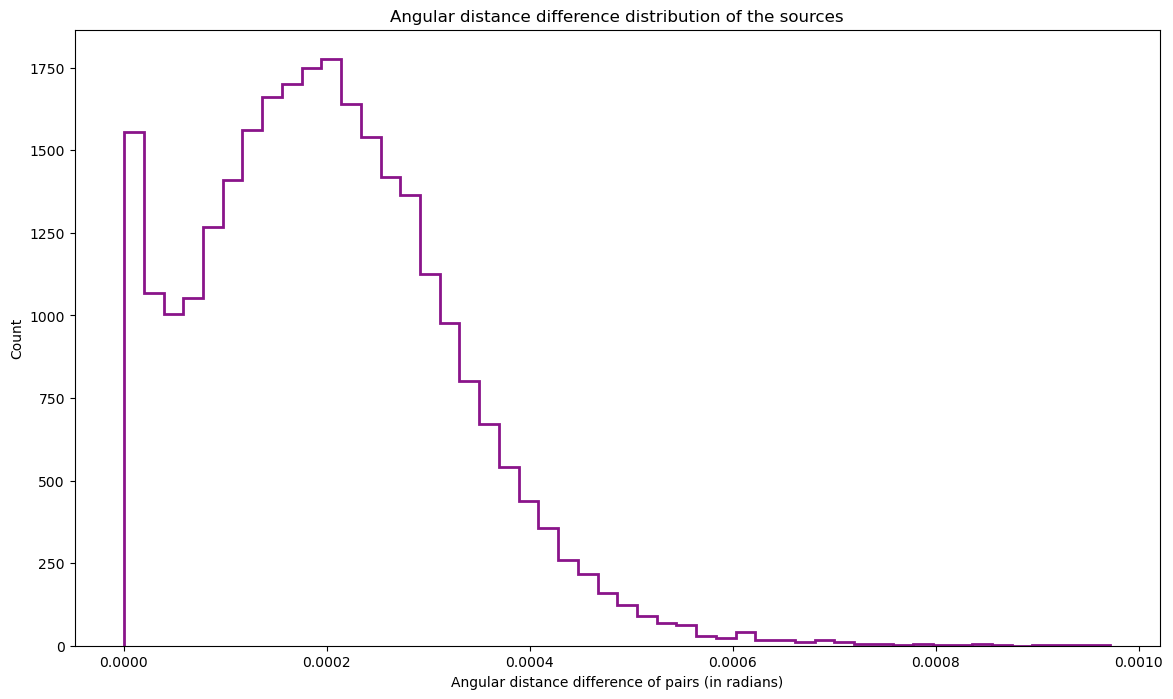

In [ ]:
plt.figure(figsize=(14, 8))
plt.hist(result["Distance"], histtype='step', color="purple", linewidth=2.0, bins=50, alpha=0.92)
plt.xlabel("Angular distance difference of pairs (in radians)")
plt.ylabel("Count")
plt.title("Angular distance difference distribution of the sources")
plt.show()

### **Normalized Distance Distribution**

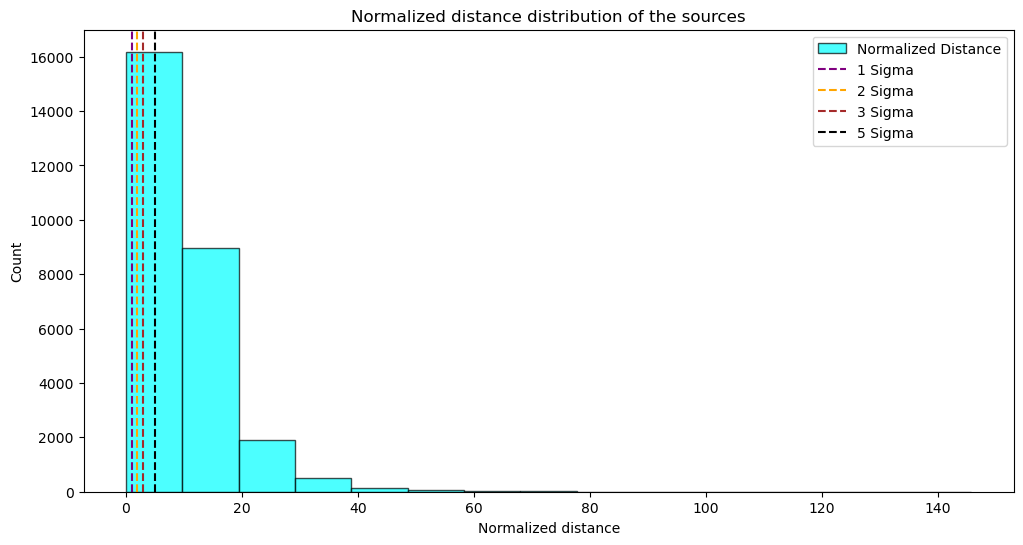

In [15]:
def arcsec_to_radian(arcsec):
    return arcsec * np.pi / (180 * 3600)

matched_delta_theta = result["RADEC_ERR"]
matched_delta_theta_radian = arcsec_to_radian(matched_delta_theta)

norm = result["Distance"]/matched_delta_theta_radian
result["Norm"] = norm

plt.figure(figsize=(12, 6))

plt.hist(norm, color='cyan', edgecolor='black', label="Normalized Distance", bins=15, alpha=0.7)
plt.axvline(x=1, color='purple', linestyle='--', label='1 Sigma')
plt.axvline(x=2, color='orange', linestyle='--', label='2 Sigma')
plt.axvline(x=3, color='brown', linestyle='--', label='3 Sigma')
plt.axvline(x=5, color='black', linestyle='--', label='5 Sigma')

plt.xlabel("Normalized distance")
plt.ylabel("Count")
plt.title("Normalized distance distribution of the sources")
plt.legend()
plt.show()

In [30]:
result

,EFEDS_ID,DESI_ID,RA,DEC,RA_2,DEC_2,RADEC_ERR,Z,ZERR,Distance,Norm
0,b'eFEDS J093700.9+010545',DESI J144.2543+01.0954,144.253833,1.095920,144.254363,1.095466,3.620423,0.050611,0.000003,0.000012,0.694313
1,b'eFEDS J091453.4+042636',DESI J138.7042+04.4495,138.722879,4.443384,138.704294,4.449502,0.807103,0.000173,0.000002,0.000341,87.034586
2,b'eFEDS J085617.8-013805',DESI J134.0742-01.6353,134.074170,-1.634745,134.074296,-1.635388,5.281139,0.059645,0.000003,0.000011,0.446931
3,b'eFEDS J084025.4+033302',DESI J130.1062+03.5504,130.106096,3.550809,130.106214,3.550436,1.394543,0.060588,0.000007,0.000007,1.009455
4,b'eFEDS J091639.7+004343',DESI J139.1559+00.7529,139.165435,0.728790,139.155940,0.752978,4.915523,0.383570,0.000094,0.000454,19.030566
...,...,...,...,...,...,...,...,...,...,...,...
27864,b'eFEDS J083437.8+033147',DESI J128.6495+03.5304,128.657728,3.529938,128.649582,3.530412,5.563801,0.165874,0.000017,0.000142,5.269715
27865,b'eFEDS J084150.6-012942',DESI J130.4575-01.4986,130.460951,-1.495223,130.457578,-1.498654,5.630289,0.000101,0.000003,0.000084,3.075615
27866,b'eFEDS J084934.9+014437',DESI J132.3895+01.7257,132.395816,1.743826,132.389527,1.725781,4.000000,0.068996,0.000019,0.000334,17.198171
27867,b'eFEDS J085654.2+011311',DESI J134.2372+01.2250,134.225928,1.219989,134.237250,1.225072,6.069979,0.105478,0.000010,0.000217,7.358600


In [17]:
filtered_result = result[result["Norm"] < 5]
filtered_result # cross-matched table

,EFEDS_ID,DESI_ID,RA,DEC,RA_2,DEC_2,RADEC_ERR,Z,ZERR,Distance,Norm
0,b'eFEDS J093700.9+010545',DESI J144.2543+01.0954,144.253833,1.095920,144.254363,1.095466,3.620423,0.050611,0.000003,0.000012,0.694313
2,b'eFEDS J085617.8-013805',DESI J134.0742-01.6353,134.074170,-1.634745,134.074296,-1.635388,5.281139,0.059645,0.000003,0.000011,0.446931
3,b'eFEDS J084025.4+033302',DESI J130.1062+03.5504,130.106096,3.550809,130.106214,3.550436,1.394543,0.060588,0.000007,0.000007,1.009455
6,b'eFEDS J091702.3-004415',DESI J139.2599-00.7382,139.259589,-0.737505,139.259947,-0.738204,3.699002,0.322446,0.000005,0.000014,0.765118
8,b'eFEDS J091401.7+050749',DESI J138.5077+05.1304,138.507473,5.130530,138.507758,5.130438,4.000000,0.301982,0.000018,0.000005,0.268222
...,...,...,...,...,...,...,...,...,...,...,...
27853,b'eFEDS J092929.3+003429',DESI J142.3767+00.5689,142.372327,0.574948,142.376726,0.568991,5.484828,0.000032,0.000002,0.000129,4.860295
27855,b'eFEDS J085443.3-005338',DESI J133.6793-00.8975,133.680797,-0.894029,133.679347,-0.897514,5.813345,0.000040,0.000001,0.000066,2.337386
27858,b'eFEDS J084053.3+003050',DESI J130.2157+00.5176,130.222326,0.514131,130.215766,0.517673,5.787224,0.000264,0.000001,0.000130,4.637091
27861,b'eFEDS J085413.9-004053',DESI J133.5609-00.6839,133.557988,-0.681521,133.560939,-0.683993,5.152472,0.267674,0.000111,0.000067,2.689436


## Plots

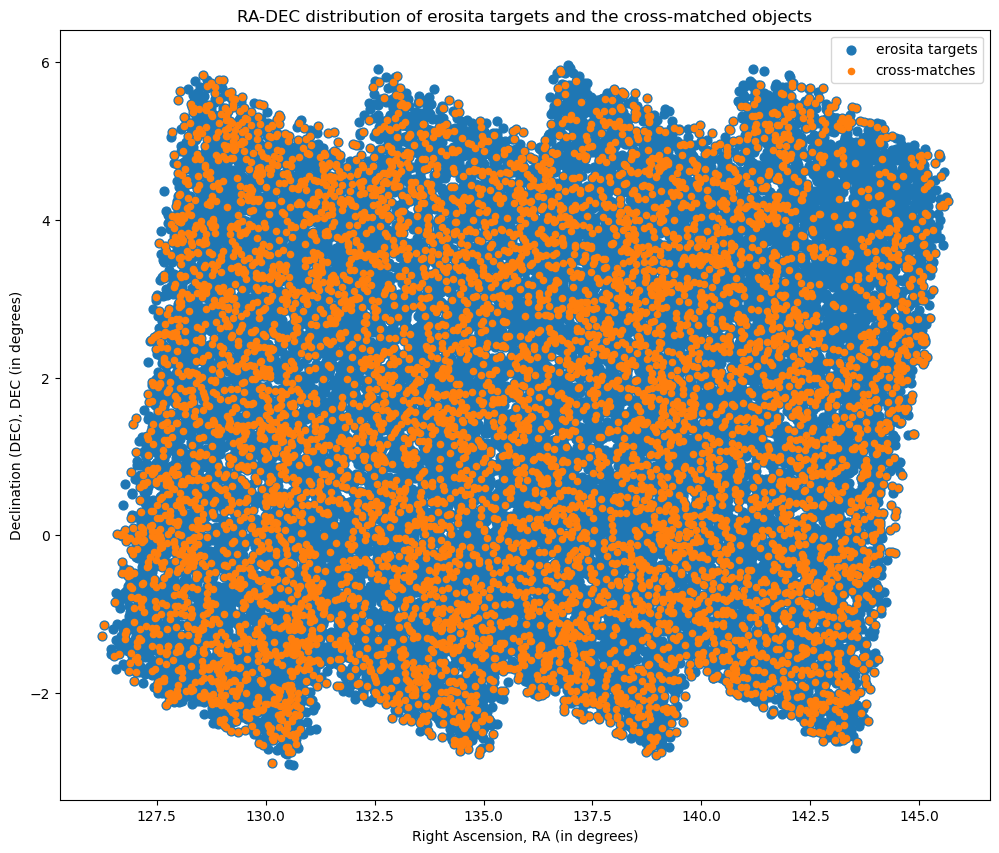

In [19]:
plt.figure(figsize=(12, 10))
plt.scatter(xray_file["RA_CORR"], xray_file["DEC_CORR"], label="erosita targets", s=40)
plt.scatter(filtered_result["RA"], filtered_result["DEC"], label='cross-matches', s=20)
plt.xlabel("Right Ascension, RA (in degrees)")
plt.ylabel("Declination (DEC), DEC (in degrees)")
plt.title("RA-DEC distribution of erosita targets and the cross-matched objects")
plt.legend()

In [26]:
desi_bgs_df = desi_bgs_table.to_pandas()

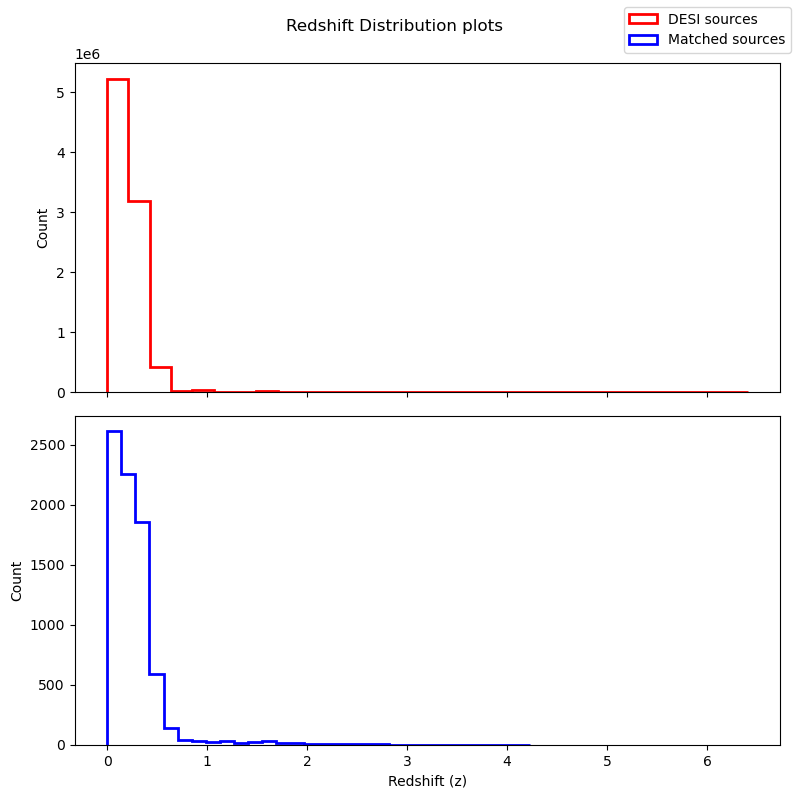

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

desi_bins = np.logspace(np.log10(max(desi_bgs_df['Z'].min(), 1e-16)), np.log10(desi_bgs_df['Z'].max()), 20)
filtered_bins = np.logspace(np.log10(max(filtered_result['Z'].min(), 1e-16)), np.log10(filtered_result['Z'].max()), 20)

ax[0].hist(desi_bgs_df['Z'], bins=30, color='red', histtype='step', linewidth=2, label='DESI sources')
ax[0].set_ylabel("Count")

ax[1].hist(filtered_result["Z"], bins=30, color='blue', histtype='step', linewidth=2, label='Matched sources')
ax[1].set_xlabel("Redshift (z)")
ax[1].set_ylabel("Count")

fig.suptitle("Redshift Distribution plots")
fig.legend()
plt.tight_layout()
#plt.xscale('log')
plt.show()

In [28]:
xray_df = xray_file.to_pandas()

matched_fluxes = filtered_result.merge(
    desi_bgs_df,
    left_on="DESI_ID",
    right_on="DESINAME",
    how="left"
).merge(
    xray_df,
    left_on="EFEDS_ID",
    right_on="Name",
    how="left",
)

In [32]:
result

,EFEDS_ID,DESI_ID,RA,DEC,RA_2,DEC_2,RADEC_ERR,Z,ZERR,Distance,Norm
0,b'eFEDS J093700.9+010545',DESI J144.2543+01.0954,144.253833,1.095920,144.254363,1.095466,3.620423,0.050611,0.000003,0.000012,0.694313
1,b'eFEDS J091453.4+042636',DESI J138.7042+04.4495,138.722879,4.443384,138.704294,4.449502,0.807103,0.000173,0.000002,0.000341,87.034586
2,b'eFEDS J085617.8-013805',DESI J134.0742-01.6353,134.074170,-1.634745,134.074296,-1.635388,5.281139,0.059645,0.000003,0.000011,0.446931
3,b'eFEDS J084025.4+033302',DESI J130.1062+03.5504,130.106096,3.550809,130.106214,3.550436,1.394543,0.060588,0.000007,0.000007,1.009455
4,b'eFEDS J091639.7+004343',DESI J139.1559+00.7529,139.165435,0.728790,139.155940,0.752978,4.915523,0.383570,0.000094,0.000454,19.030566
...,...,...,...,...,...,...,...,...,...,...,...
27864,b'eFEDS J083437.8+033147',DESI J128.6495+03.5304,128.657728,3.529938,128.649582,3.530412,5.563801,0.165874,0.000017,0.000142,5.269715
27865,b'eFEDS J084150.6-012942',DESI J130.4575-01.4986,130.460951,-1.495223,130.457578,-1.498654,5.630289,0.000101,0.000003,0.000084,3.075615
27866,b'eFEDS J084934.9+014437',DESI J132.3895+01.7257,132.395816,1.743826,132.389527,1.725781,4.000000,0.068996,0.000019,0.000334,17.198171
27867,b'eFEDS J085654.2+011311',DESI J134.2372+01.2250,134.225928,1.219989,134.237250,1.225072,6.069979,0.105478,0.000010,0.000217,7.358600


In [31]:
# Check whether the DESI merge key is unique
print("filtered_result rows:", len(result))
print("desi_dr1_df rows:", len(desi_bgs_df))

print("Duplicate DESI_IDs in filtered_result:", result["DESI_ID"].duplicated().sum())
print("Duplicate DESINAMEs in desi_dr1_df:", desi_bgs_df["DESINAME"].duplicated().sum())

# Show the actual duplicate keys in DESI
desi_dupes = desi_bgs_df[desi_bgs_df["DESINAME"].duplicated(keep=False)].sort_values("DESINAME")
print("Duplicated DESINAME values:")
display(desi_dupes[["DESINAME", "TARGET_RA", "TARGET_DEC", "Z", "ZERR", 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2']])

# See whether any filtered_result keys repeat too
filtered_dupes = result[result["DESI_ID"].duplicated(keep=False)].sort_values("DESI_ID")
print("Duplicated DESI_ID values in filtered_result:")
display(filtered_dupes[["DESI_ID", "EFEDS_ID", "RA", "DEC"]])

filtered_result rows: 27869
desi_dr1_df rows: 8915387
Duplicate DESI_IDs in filtered_result: 1640
Duplicate DESINAMEs in desi_dr1_df: 0
Duplicated DESINAME values:


,DESINAME,TARGET_RA,TARGET_DEC,Z,ZERR,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2


Duplicated DESI_ID values in filtered_result:


,DESI_ID,EFEDS_ID,RA,DEC
3843,DESI J126.6222-01.3874,b'eFEDS J082632.6-012313',126.635974,-1.387107
3842,DESI J126.6222-01.3874,b'eFEDS J082628.7-012300',126.619919,-1.383335
25427,DESI J126.6866000.-86,b'eFEDS J082643.8+000003',126.682664,0.001029
25426,DESI J126.6866000.-86,b'eFEDS J082648.2-000033',126.700861,-0.009309
15890,DESI J126.9090-00.1821,b'eFEDS J082739.4-001102',126.914318,-0.184110
...,...,...,...,...
317,DESI J145.2383+03.4003,b'eFEDS J094054.0+032450',145.225177,3.414033
9344,DESI J145.2631+04.2976,b'eFEDS J094105.3+041703',145.272333,4.284267
20612,DESI J145.2631+04.2976,b'eFEDS J094059.7+041655',145.249069,4.282012
24381,DESI J145.2837+03.4281,b'eFEDS J094108.0+032422',145.283725,3.406354


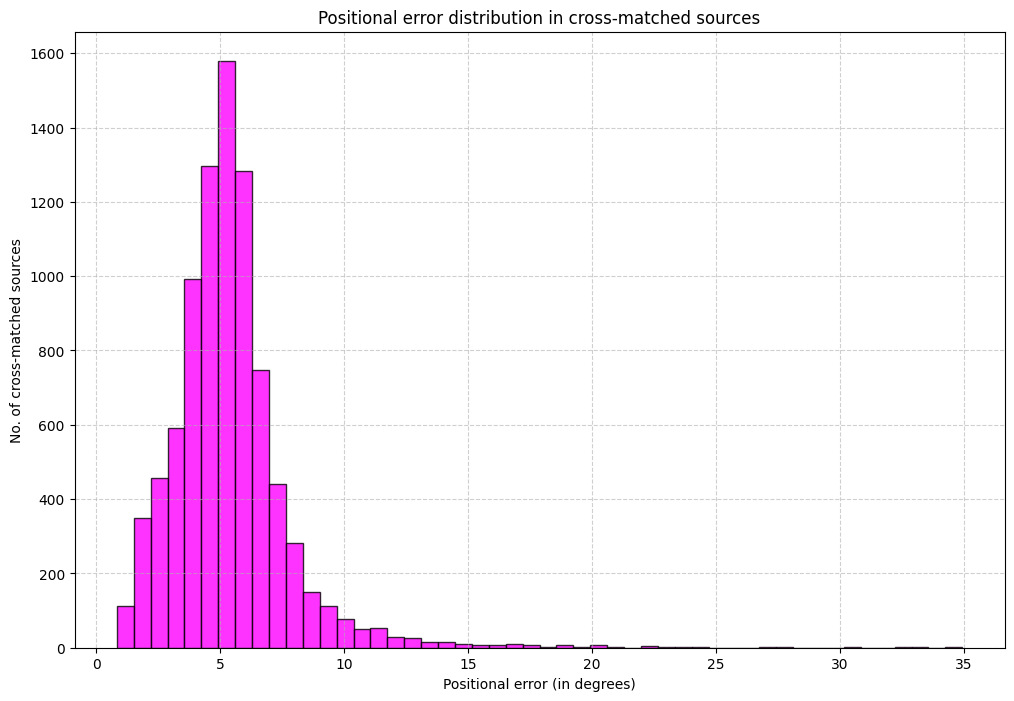

In [55]:
plt.figure(figsize=(12, 8))
plt.hist(matched_fluxes['RADEC_ERR'], color='magenta', edgecolor='black', alpha=0.8, bins=50)
plt.xlabel("Positional error (in degrees)")
plt.ylabel("No. of cross-matched sources")
plt.title("Positional error distribution in cross-matched sources")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

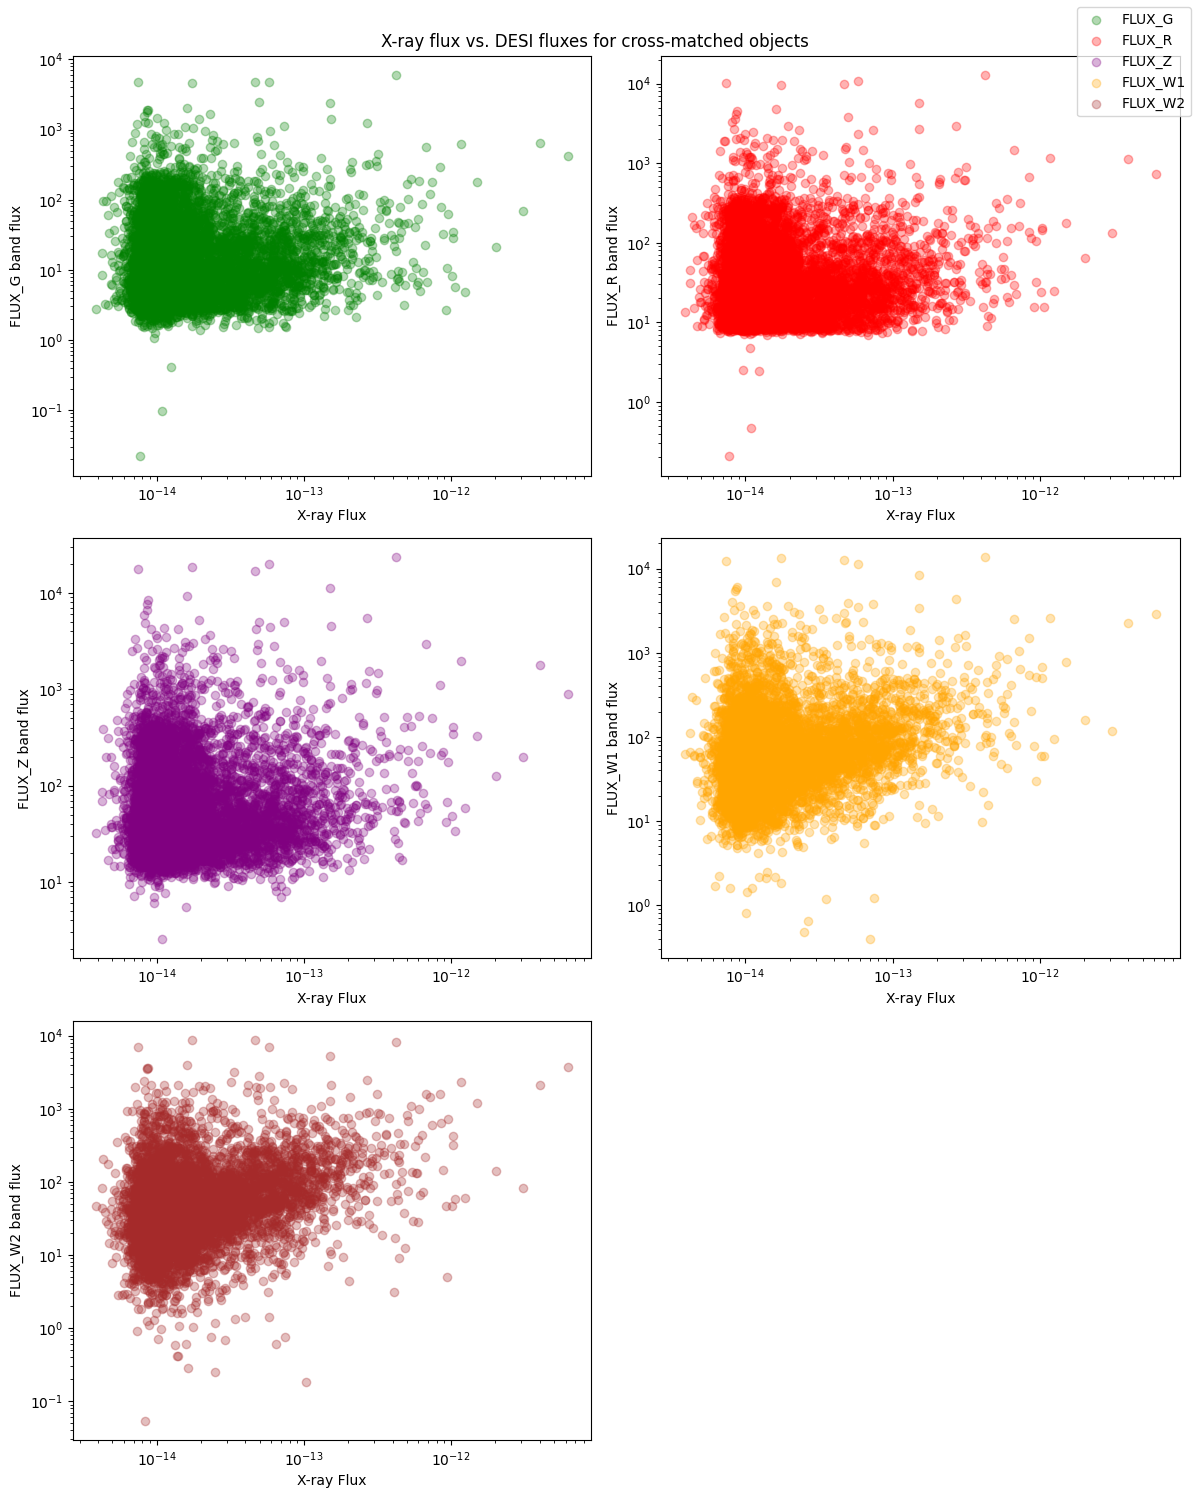

In [57]:
bands = ['FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2']
shades = ['green', 'red', 'purple', 'orange', 'brown']

fig, ax = plt.subplots(3, 2, figsize=(12, 15))
axes = ax.flatten()

for i in range(len(bands)):
    axes[i].scatter(matched_fluxes["ML_FLUX"], matched_fluxes[bands[i]], color=shades[i], alpha=0.3, label=f'{bands[i]}')
    axes[i].set_xlabel("X-ray Flux")
    axes[i].set_ylabel(f"{bands[i]} band flux")
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

axes[5].axis('off')

fig.suptitle("X-ray flux vs. DESI fluxes for cross-matched objects")
fig.legend()
plt.tight_layout()
plt.show()

In [58]:
unmatched_xray_fluxes = xray_df[~xray_df['Name'].isin(matched_fluxes['EFEDS_ID'])]
unmatched_xray_fluxes

,Name,RA_CORR,DEC_CORR,RADEC_ERR_CORR,ML_FLUX,ML_FLUX_ERR
1,b'eFEDS J091453.4+042636',138.722879,4.443384,0.807103,4.424652e-12,7.132479e-14
4,b'eFEDS J091639.7+004343',139.165435,0.728790,4.915523,2.034448e-12,2.411126e-13
5,b'eFEDS J084441.9+004416',131.174734,0.737925,0.944461,1.890855e-12,4.765892e-14
7,b'eFEDS J091400.3+050651',138.501628,5.114248,1.915613,1.449183e-13,1.402806e-14
9,b'eFEDS J091408.2-015944',138.534321,-1.995670,0.813150,1.001176e-12,2.415655e-14
...,...,...,...,...,...,...
27904,b'eFEDS J090204.6-000356',135.519225,-0.065732,5.965186,6.791384e-15,2.788712e-15
27905,b'eFEDS J083437.8+033147',128.657728,3.529938,5.563801,6.807719e-15,2.923182e-15
27907,b'eFEDS J084934.9+014437',132.395816,1.743826,4.000000,2.009711e-13,3.578497e-14
27908,b'eFEDS J085654.2+011311',134.225928,1.219989,6.069979,8.340650e-15,3.433873e-15


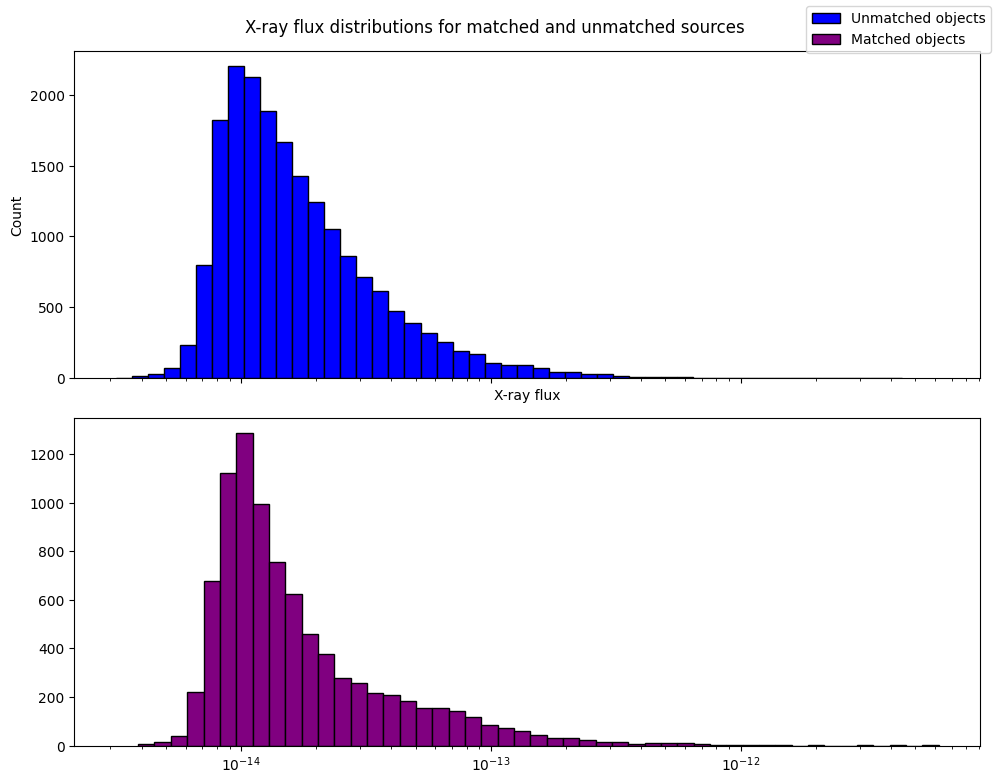

In [59]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

un_bins = np.logspace(np.log10(unmatched_xray_fluxes['ML_FLUX'].min()), np.log10(unmatched_xray_fluxes['ML_FLUX'].max()), 50)
bins = np.logspace(np.log10(matched_fluxes['ML_FLUX'].min()), np.log10(matched_fluxes['ML_FLUX'].max()), 50)


ax[0].hist(unmatched_xray_fluxes['ML_FLUX'], color='blue', edgecolor='black', bins=un_bins, label='Unmatched objects')
ax[0].set_xlabel("X-ray flux") #TODO: get units for the flux
ax[0].set_ylabel("Count")

ax[1].hist(matched_fluxes['ML_FLUX'], color='purple', edgecolor='black', bins=bins, label='Matched objects')
ax[0].set_ylabel("Count")

fig.suptitle("X-ray flux distributions for matched and unmatched sources")
fig.legend()

plt.tight_layout()
plt.xscale('log')
plt.show()

In [61]:
unmatched_desi_fluxes = desi_dr1_df[~desi_dr1_df['DESINAME'].isin(matched_fluxes['DESI_ID'])]
unmatched_desi_fluxes

,Z,ZERR,TARGET_RA,TARGET_DEC,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,DESINAME
0,0.363967,0.000045,44.383188,0.609118,2.358985,7.854418,17.424397,26.047333,19.360781,DESI J044.3831+00.6091
1,0.393695,0.000041,44.474222,0.599860,10.030748,40.470177,91.119705,147.354065,95.014565,DESI J044.4742+00.5998
2,0.285620,0.000062,44.505206,0.652012,16.777256,61.168995,134.152039,14.039649,-32.875656,DESI J044.5052+00.6520
3,0.163577,0.000016,44.396078,0.673949,15.839828,32.624561,59.066883,60.633934,43.454411,DESI J044.3960+00.6739
4,0.267935,0.000016,44.424091,0.662135,3.021409,7.540901,14.070936,16.859579,9.890833,DESI J044.4240+00.6621
...,...,...,...,...,...,...,...,...,...,...
11020465,0.518469,0.000083,234.552043,49.822069,0.000000,0.000000,0.000000,0.000000,0.000000,DESI J234.5520+49.8220
11020466,0.062305,0.000002,234.506565,49.872203,10.546790,14.905501,17.501884,10.364157,4.737359,DESI J234.5065+49.8722
11020467,0.370581,0.000101,234.022735,48.953505,2.188500,11.091904,24.786507,42.642471,26.719149,DESI J234.0227+48.9535
11020468,0.634406,0.000065,238.664026,48.777178,0.000000,0.000000,0.000000,0.000000,0.000000,DESI J238.6640+48.7771


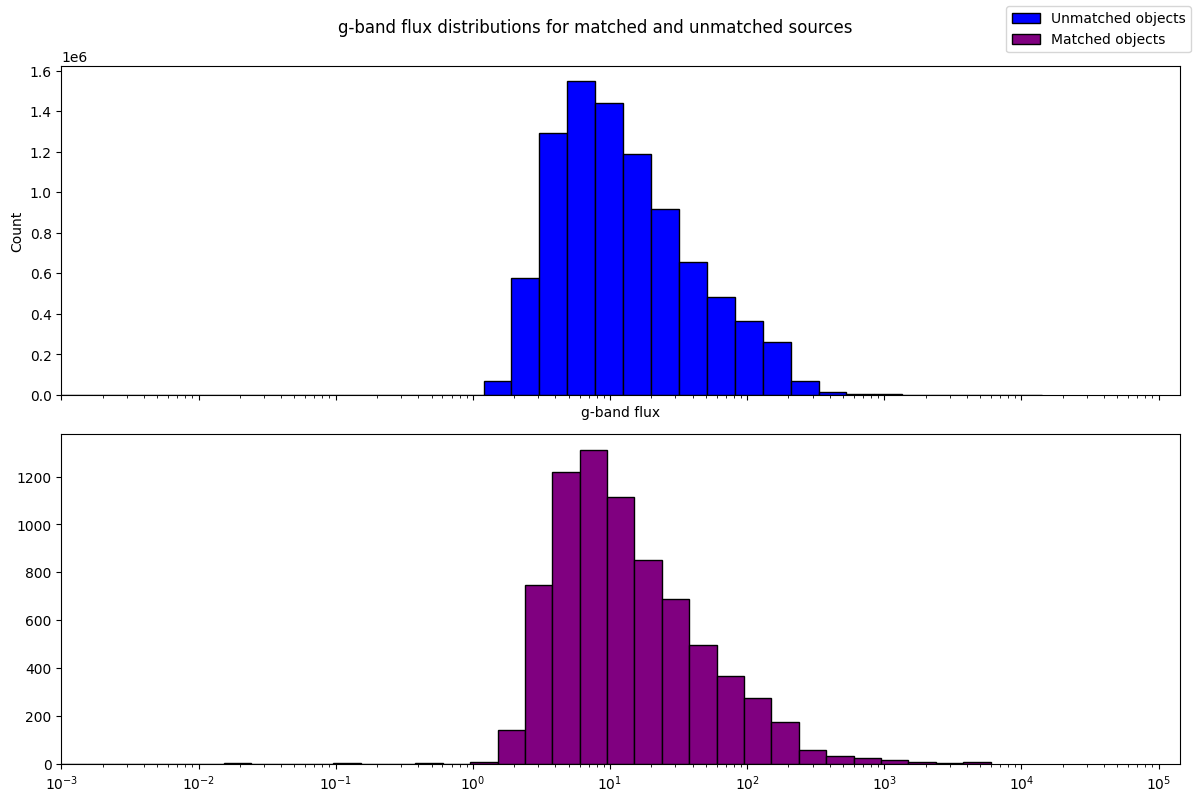

In [69]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bins_g = np.logspace(np.log10(max(unmatched_desi_fluxes['FLUX_G'].min(), 1e-16)), np.log10(unmatched_desi_fluxes['FLUX_G'].max()), 100)
bins_matched = np.logspace(np.log10(max(matched_fluxes['FLUX_G'].min(), 1e-16)), np.log10(matched_fluxes['FLUX_G'].max()), 100)

ax[0].hist(unmatched_desi_fluxes['FLUX_G'], color='blue', edgecolor='black', bins=bins_g, label='Unmatched objects')
ax[0].set_xlabel("g-band flux")
ax[0].set_ylabel("Count")

ax[1].hist(matched_fluxes['FLUX_G'], color='purple', edgecolor='black', bins=bins_matched, label='Matched objects')
ax[0].set_ylabel("Count")

fig.suptitle("g-band flux distributions for matched and unmatched sources")
fig.legend()

plt.tight_layout()
plt.xscale('log')
plt.xlim(left=1e-3)
plt.show()

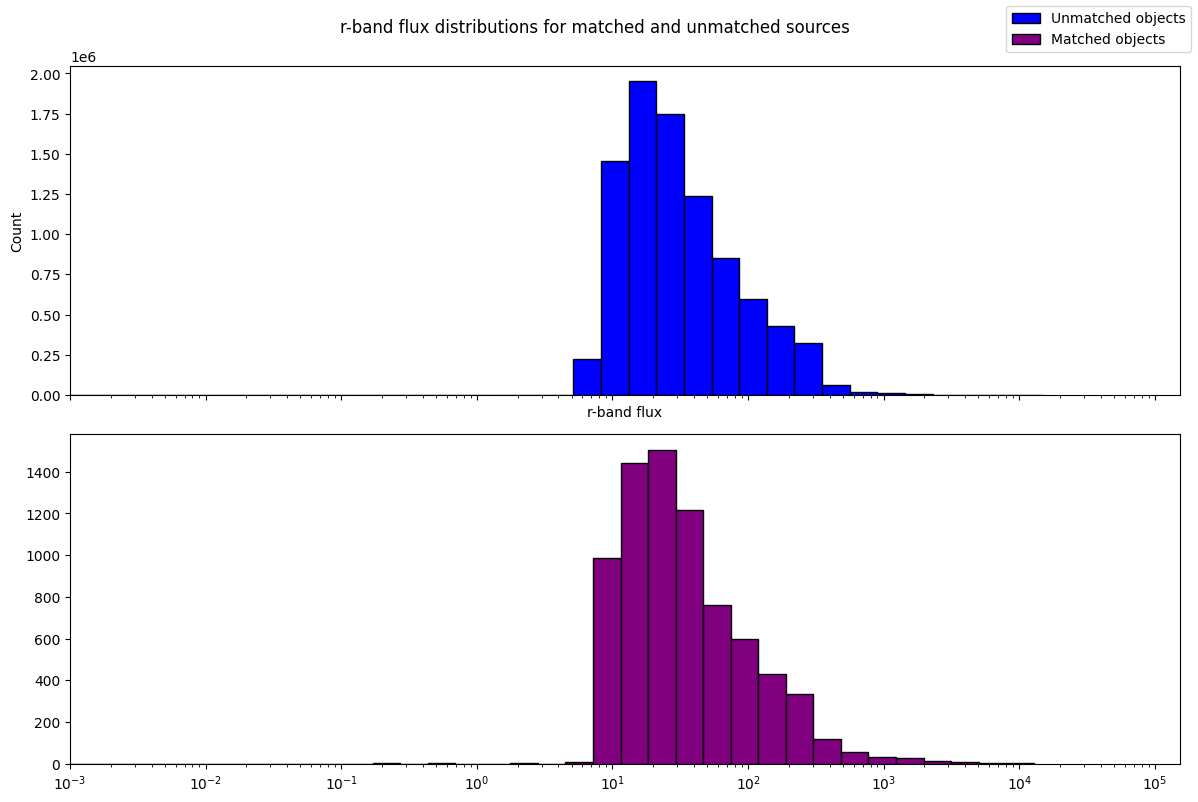

In [70]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bins_g = np.logspace(np.log10(max(unmatched_desi_fluxes['FLUX_R'].min(), 1e-16)), np.log10(unmatched_desi_fluxes['FLUX_R'].max()), 100)
bins_matched = np.logspace(np.log10(max(matched_fluxes['FLUX_R'].min(), 1e-16)), np.log10(matched_fluxes['FLUX_R'].max()), 100)

ax[0].hist(unmatched_desi_fluxes['FLUX_R'], color='blue', edgecolor='black', bins=bins_g, label='Unmatched objects')
ax[0].set_xlabel("r-band flux")
ax[0].set_ylabel("Count")

ax[1].hist(matched_fluxes['FLUX_R'], color='purple', edgecolor='black', bins=bins_matched, label='Matched objects')
ax[0].set_ylabel("Count")

fig.suptitle("r-band flux distributions for matched and unmatched sources")
fig.legend()

plt.tight_layout()
plt.xscale('log')
plt.xlim(left=1e-3)
plt.show()

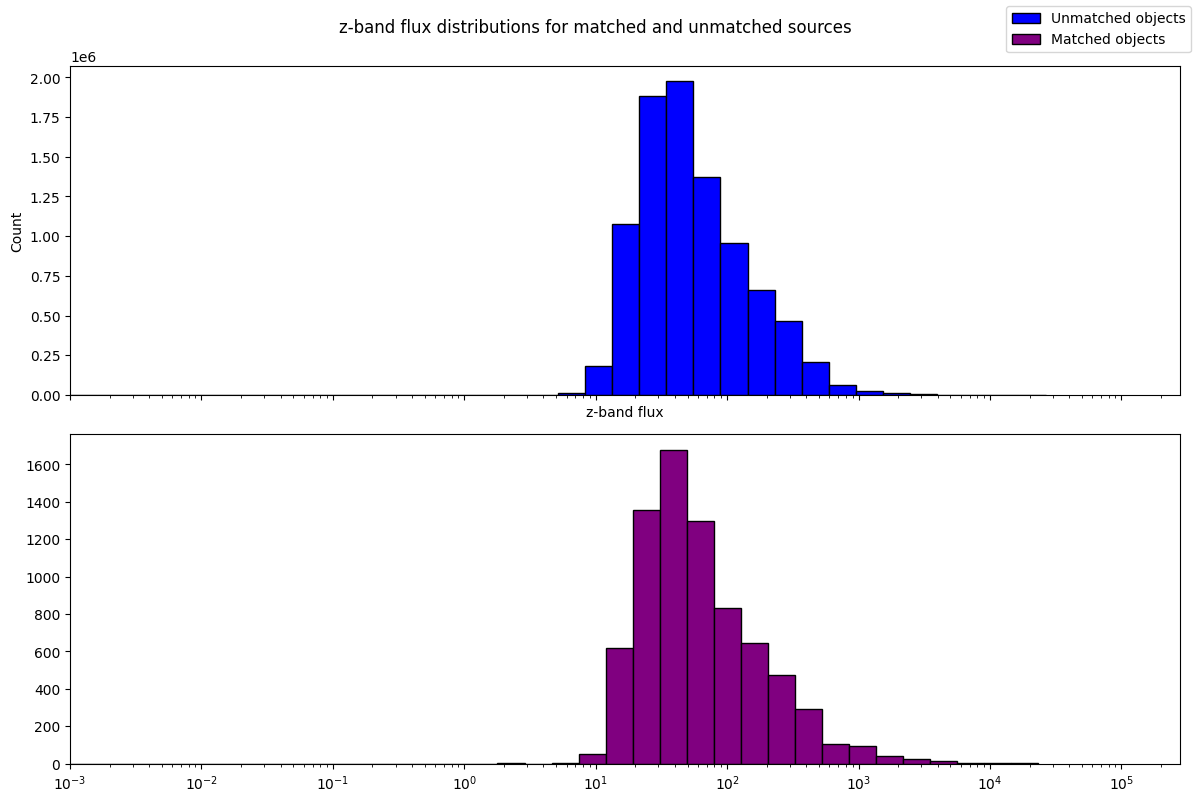

In [71]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bins_g = np.logspace(np.log10(max(unmatched_desi_fluxes['FLUX_Z'].min(), 1e-16)), np.log10(unmatched_desi_fluxes['FLUX_Z'].max()), 100)
bins_matched = np.logspace(np.log10(max(matched_fluxes['FLUX_Z'].min(), 1e-16)), np.log10(matched_fluxes['FLUX_Z'].max()), 100)

ax[0].hist(unmatched_desi_fluxes['FLUX_Z'], color='blue', edgecolor='black', bins=bins_g, label='Unmatched objects')
ax[0].set_xlabel("z-band flux")
ax[0].set_ylabel("Count")

ax[1].hist(matched_fluxes['FLUX_Z'], color='purple', edgecolor='black', bins=bins_matched, label='Matched objects')
ax[0].set_ylabel("Count")

fig.suptitle("z-band flux distributions for matched and unmatched sources")
fig.legend()

plt.tight_layout()
plt.xscale('log')
plt.xlim(left=1e-3)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

In [6]:
cross_matched_data = fits.open('data/crossmatched_fluxes.fits')
cross_matched_table = Table(cross_matched_data[1].data)
cross_matched_table

EFEDS_ID,DESI_ID,RA,DEC,RA_2,DEC_2,RADEC_ERR,Z_1,ZERR_1,Distance,Norm,ML_FLUX,ML_FLUX_ERR,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_ERR_G,FLUX_ERR_R,FLUX_ERR_Z,FLUX_ERR_W1,FLUX_ERR_W2
str22,str22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
eFEDS J093700.9+010545,DESI J144.2543+01.0954,144.25383285520846,1.0959204090623735,144.25436345973188,1.0954664066554602,3.6204234764894245,0.05061091954760733,2.661663656092744e-06,1.2186802641200775e-05,0.6943133867854375,6.2095207e-12,3.7595803e-13,1.519314568848307,2.6469391848506776,3.213964325882871,10.382542292669852,13.405392249573065,0.0007244552801817526,0.0011129268461655315,0.0012933123600083393,0.009497934805328644,0.016690259455405306
eFEDS J085617.8-013805,DESI J134.0742-01.6353,134.07417045497337,-1.6347450374969688,134.07429642882974,-1.6353884713279225,5.281138955203107,0.05964545847073229,3.1033085161648927e-06,1.144307381419047e-05,0.446930751714039,3.993971e-12,3.462835e-13,2.315231127197975,4.142331022883219,6.491148642989461,8.089793018899888,7.5443090169752605,0.0014910606987411008,0.0025387805568925117,0.004730299940094761,0.011393262457684192,0.018786213024892195
eFEDS J084025.4+033302,DESI J130.1062+03.5504,130.10609617356337,3.5508089298077246,130.10621431848094,3.550436096947745,1.3945431648151174,0.06058824633448142,7.2087299723337284e-06,6.824862772858242e-06,1.0094553062423541,3.0862292e-12,8.368503e-14,0.253821011623094,0.48334439173513577,0.7156944023147782,0.4217461354904165,0.29445701709551003,0.0004790641074472169,0.0009544580911805267,0.0014714954243906706,0.0060440936419810555,0.011061986704974268
eFEDS J091702.3-004415,DESI J139.2599-00.7382,139.25958886351057,-0.7375046618167612,139.25994749778755,-0.7382042687878796,3.6990023966831513,0.3224457362718547,4.909902728692486e-06,1.3721076051898567e-05,0.7651184805623035,1.509369e-12,3.2599903e-14,0.6388767678591497,0.6374315691688529,1.1758520142961095,2.833997734397679,4.339158153809822,0.00047818075830695925,0.0006191816476804967,0.0007741425325550777,0.005322730303643349,0.010173114927570032
eFEDS J091401.7+050749,DESI J138.5077+05.1304,138.5074734496979,5.130529581471579,138.50775809857717,5.130437701944883,4.0,0.3019822858360396,1.842973246279598e-05,5.201517150447805e-06,0.2682224818070163,2.021173e-12,4.658158e-14,0.07548187413698149,0.23403783932683145,0.46165394608491833,0.579487334323269,0.5143295713219573,0.0004391978474193602,0.0008086183044477245,0.0017489048214314627,0.007132953101732025,0.01407680182613227
eFEDS J083702.1+024535,DESI J129.2590+02.7600,129.25886946373137,2.759877378658286,129.2590701156623,2.760021238402743,0.8216912851507777,0.08207181813079095,1.0864565034179787e-05,4.305818872289462e-06,1.0808668796638217,7.367125e-13,2.4930351e-14,0.6435241071267926,1.162297639490816,1.8110516861086203,2.3307778440756532,2.14782076464442,0.0005211876063942869,0.0010088207893612206,0.0012764373220291898,0.0053900795769185736,0.008894467543817805
eFEDS J084110.8+022950,DESI J130.2953+02.4978,130.29519680015477,2.4974523884309074,130.2953395776523,2.4978213243083998,0.9817019161810577,0.3351263274963502,3.734115916718102e-05,6.903662776589209e-06,1.450524483590634,6.6891165e-13,2.3873835e-14,0.08204030944928502,0.10748217893471937,0.23449467856627915,0.5408613716432252,0.7889620313392597,0.0002521564887982117,0.0004152531310746512,0.0005626694312157544,0.0032094960303984893,0.006027340509187916
eFEDS J093712.8+031651,DESI J144.2995+03.2787,144.3035678286463,3.281043248079495,144.29956158749744,3.2787917801802755,4.0,0.2613960268092464,6.976195180350713e-05,8.010757253023202e-05,4.130843231718381,6.549241e-14,1.2588066e-14,0.00846124626351351,0.03224159137275652,0.06604674634425989,0.07255757807707085,0.08643166694323101,0.00012784608091198751,0.0002427086379456622,0.00044045925155335435,0.002255843565601647,0.00460417101880405
eFEDS J083834.1-002439,DESI J129.6420-00

In [ ]:
def ivarToError(ivar):
    return np.sqrt(1/ivar)

def nanomaggyToAB(flux_in_nanomaggy):
    if flux_in_nanomaggy:
        return 22.5 - 2.5*np.log10(flux_in_nanomaggy)
    else:
        print("Empty flux array submitted")

def abToJansky(mag_ab, order=1):
    orders = dict(kilo=1e-3, milli=1e+3, nano=1e+9)

    if order in orders.keys():
        order_num = orders[order]
    else:
        order_num = order

    return 10**(23-(mag_ab + 48.6)/2.5)*order_num

In [ ]:
#TODO: create corresponding error columns for ivar columns

ivar_columns = np.array(input("Please type in the list of column names to be converted: "))
for column in ivar_columns:
    err_column = ivarToError(column)
    filtered_result[f'{column}_err'] = err_column

#TODO: convert the fluxes in nanomaggies to fluxes in milli Janskies (mJy)

flux_columns = np.array(input("Please type in the list of column names to be converted: "))
for column in flux_columns:
    mag_ab = nanomaggyToAB(column)
    flux_Jy = abToJansky(column, order='milli')
    filtered_result[column] = flux_Jy

In [3]:
import numpy as np
import scipy.constants as cst
nu_1keV = 1e3*cst.eV / cst.h

def convt_Fx_to_Fnu(flux, flux_err, Elo, Eup):
    '''
    Convert X-ray flux to flux density
    Input:
        flux, flux of an X-ray band (untis: erg/s/cm2)
              array-like objects
        flux_err, the uncertainty of flux
        Elo, Eup: observed-frame energy range of flux_xray (units: keV)
    Output:
        Fnu, X-ray flux density (units: mJy)
        Fnu_err, the error of Fnu
    '''
    Fnu = np.array(flux) / (nu_1keV * (Eup-Elo) * 1e-26)
    Fnu_err = np.array(flux_err) / (nu_1keV * (Eup-Elo) * 1e-26)

    return Fnu, Fnu_err


In [7]:
cross_matched_table['ML_FLUX_DENSITY'], cross_matched_table['ML_FLUX_DENSITY_ERR'] = convt_Fx_to_Fnu(cross_matched_table['ML_FLUX'], cross_matched_table['ML_FLUX_ERR'], 0.2, 2.3)
cross_matched_table

EFEDS_ID,DESI_ID,RA,DEC,RA_2,DEC_2,RADEC_ERR,Z_1,ZERR_1,Distance,Norm,ML_FLUX,ML_FLUX_ERR,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_ERR_G,FLUX_ERR_R,FLUX_ERR_Z,FLUX_ERR_W1,FLUX_ERR_W2,ML_FLUX_DENSITY,ML_FLUX_DENSITY_ERR
str22,str22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32
eFEDS J093700.9+010545,DESI J144.2543+01.0954,144.25383285520846,1.0959204090623735,144.25436345973188,1.0954664066554602,3.6204234764894245,0.05061091954760733,2.661663656092744e-06,1.2186802641200775e-05,0.6943133867854375,6.2095207e-12,3.7595803e-13,1.519314568848307,2.6469391848506776,3.213964325882871,10.382542292669852,13.405392249573065,0.0007244552801817526,0.0011129268461655315,0.0012933123600083393,0.009497934805328644,0.016690259455405306,0.0012228816,7.403988e-05
eFEDS J085617.8-013805,DESI J134.0742-01.6353,134.07417045497337,-1.6347450374969688,134.07429642882974,-1.6353884713279225,5.281138955203107,0.05964545847073229,3.1033085161648927e-06,1.144307381419047e-05,0.446930751714039,3.993971e-12,3.462835e-13,2.315231127197975,4.142331022883219,6.491148642989461,8.089793018899888,7.5443090169752605,0.0014910606987411008,0.0025387805568925117,0.004730299940094761,0.011393262457684192,0.018786213024892195,0.0007865589,6.819588e-05
eFEDS J084025.4+033302,DESI J130.1062+03.5504,130.10609617356337,3.5508089298077246,130.10621431848094,3.550436096947745,1.3945431648151174,0.06058824633448142,7.2087299723337284e-06,6.824862772858242e-06,1.0094553062423541,3.0862292e-12,8.368503e-14,0.253821011623094,0.48334439173513577,0.7156944023147782,0.4217461354904165,0.29445701709551003,0.0004790641074472169,0.0009544580911805267,0.0014714954243906706,0.0060440936419810555,0.011061986704974268,0.00060779136,1.6480642e-05
eFEDS J091702.3-004415,DESI J139.2599-00.7382,139.25958886351057,-0.7375046618167612,139.25994749778755,-0.7382042687878796,3.6990023966831513,0.3224457362718547,4.909902728692486e-06,1.3721076051898567e-05,0.7651184805623035,1.509369e-12,3.2599903e-14,0.6388767678591497,0.6374315691688529,1.1758520142961095,2.833997734397679,4.339158153809822,0.00047818075830695925,0.0006191816476804967,0.0007741425325550777,0.005322730303643349,0.010173114927570032,0.00029724994,6.4201126e-06
eFEDS J091401.7+050749,DESI J138.5077+05.1304,138.5074734496979,5.130529581471579,138.50775809857717,5.130437701944883,4.0,0.3019822858360396,1.842973246279598e-05,5.201517150447805e-06,0.2682224818070163,2.021173e-12,4.658158e-14,0.07548187413698149,0.23403783932683145,0.46165394608491833,0.579487334323269,0.5143295713219573,0.0004391978474193602,0.0008086183044477245,0.0017489048214314627,0.007132953101732025,0.01407680182613227,0.00039804284,9.1736165e-06
eFEDS J083702.1+024535,DESI J129.2590+02.7600,129.25886946373137,2.759877378658286,129.2590701156623,2.760021238402743,0.8216912851507777,0.08207181813079095,1.0864565034179787e-05,4.305818872289462e-06,1.0808668796638217,7.367125e-13,2.4930351e-14,0.6435241071267926,1.162297639490816,1.8110516861086203,2.3307778440756532,2.14782076464442,0.0005211876063942869,0.0010088207893612206,0.0012764373220291898,0.0053900795769185736,0.008894467543817805,0.00014508562,4.9096975e-06
eFEDS J084110.8+022950,DESI J130.2953+02.4978,130.29519680015477,2.4974523884309074,130.2953395776523,2.4978213243083998,0.9817019161810577,0.3351263274963502,3.734115916718102e-05,6.903662776589209e-06,1.450524483590634,6.6891165e-13,2.3873835e-14,0.08204030944928502,0.10748217893471937,0.23449467856627915,0.5408613716432252,0.7889620313392597,0.0002521564887982117,0.0004152531310746512,0.0005626694312157544,0.0032094960303984893,0.006027340509187916,0.00013173316,4.701631e-06
eFEDS J093712.8+031651,DESI J144.2995+03.2787,144.3035678286463,3.281043248079495,144.29956158749744,3.2787917801802755,4.0,0.2613960268092464,6.976195180350713e-05,8.010757253023202e-05,4.130843231718381,6.549241e-14,1.2588066e-14,0.0084

In [8]:
cross_matched_table.write('crossmatched_updated.fits', overwrite=True)

### Creating the normalized filter files for CIGALE

In [9]:
import numpy as np
import scipy.constants as cst

# Define wavelenght (units: nm) corresponding to 1 keV
lam_1keV = 1e9*cst.c*cst.h / (1e3*cst.eV)

# Write a box-car filter
def write_boxcar_filter(file_name, filter_name, E_lo, E_up, phot_ct=False, desc='no description'):
    '''
    Input:
        file_name, the file name to output
        filter_name, the name of the filter
                     should be different from any existing name
        E_lo, E_up: energy range of the filter, units: keV
    Keywords:
        phot_ct, True=photon counter
                 Falsse=energy counter
        desc, some descriptions in string
    Output:
        lams, wavelength in nm
        trans, fractional transmission
    '''
    # Get the corresponding wavelength
    lam_lo, lam_up = lam_1keV/E_up, lam_1keV/E_lo
    # Generate the grids
    lams = np.logspace(np.log10(lam_lo), np.log10(lam_up), 100)
    # Set the transmission profile
    trans = np.zeros(len(lams))+1.
    trans[0], trans[-1] = 0, 0

    with open(file_name, mode='w') as file:
        # Write the filter name
        file.write('# ' + filter_name + '\n')
        # Write filter type
        if phot_ct: file.write('# photon\n')
        else: file.write('# energy\n')
        # Write the description
        file.write('# ' + desc + '\n')
        # Wrtie the transmission curve
        # Note that cigale filter is in format of A
        # so need to multiply lam by a factor of 10
        # to convert nm to A
        for lam, tran in zip(lams, trans):
            file.write("%.4e %.3f \n" %(lam*10, tran))

    return None


In [10]:
write_boxcar_filter('efeds_flux.dat', 'efeds_flux', 0.2, 2.3)

In [6]:
def normalize_filter(transmission: np.ndarray) -> np.ndarray | str:
    peak = np.max(transmission)

    if peak != 0:
        scale_factor = 1/peak
        normalized_transmission = transmission * scale_factor
        return normalized_transmission
    else:
        return "Peak transmission is zero. Open the telescope!"

In [3]:
desi_filters = fits.open('data/desi_filter_files.fits')
desi_filters_table = Table(desi_filters[1].data)
desi_filters_table

LAMBDA,g,r,i,z,Y,atm
float32,float32,float32,float32,float32,float32,float32
3800.0,0.0,0.0,0.0,0.0,0.0,0.60928
3805.0,0.00024,0.0,0.0,0.0,0.0,0.61078
3810.0,0.00048,0.0,0.0,0.0,0.0,0.61227
3815.0,0.00054,0.0,0.0,0.0,0.0,0.61371
3820.0,0.0006,0.0,0.0,0.0,0.0,0.6152
3825.0,0.0006,0.0,0.0,0.0,0.0,0.61661
3830.0,0.0006,0.0,0.0,0.0,0.0,0.61805
3835.0,0.0007,0.0,0.0,0.0,0.0,0.61933
3840.0,0.00079,0.0,0.0,0.0,0.0,0.62064


In [4]:
type(np.array(desi_filters_table['g']))

numpy.ndarray

In [7]:
filters_list = ['g', 'r', 'z']

for filter in filters_list:
    desi_filters_table[f'{filter}_normalized'] = normalize_filter(np.array(desi_filters_table[f'{filter}']))

desi_filters_table

LAMBDA,g,r,i,z,Y,atm,g_normalized,r_normalized,z_normalized
float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
3800.0,0.0,0.0,0.0,0.0,0.0,0.60928,0.0,0.0,0.0
3805.0,0.00024,0.0,0.0,0.0,0.0,0.61078,0.0003540606,0.0,0.0
3810.0,0.00048,0.0,0.0,0.0,0.0,0.61227,0.0007081212,0.0,0.0
3815.0,0.00054,0.0,0.0,0.0,0.0,0.61371,0.0007966364,0.0,0.0
3820.0,0.0006,0.0,0.0,0.0,0.0,0.6152,0.0008851516,0.0,0.0
3825.0,0.0006,0.0,0.0,0.0,0.0,0.61661,0.0008851516,0.0,0.0
3830.0,0.0006,0.0,0.0,0.0,0.0,0.61805,0.0008851516,0.0,0.0
3835.0,0.0007,0.0,0.0,0.0,0.0,0.61933,0.0010326768,0.0,0.0
3840.0,0.00079,0.0,0.0,0.0,0.0,0.62064,0.0011654496,0.0,0.0


In [8]:
desi_filters_table.write('desi_filters_normalized.fits', overwrite=True)